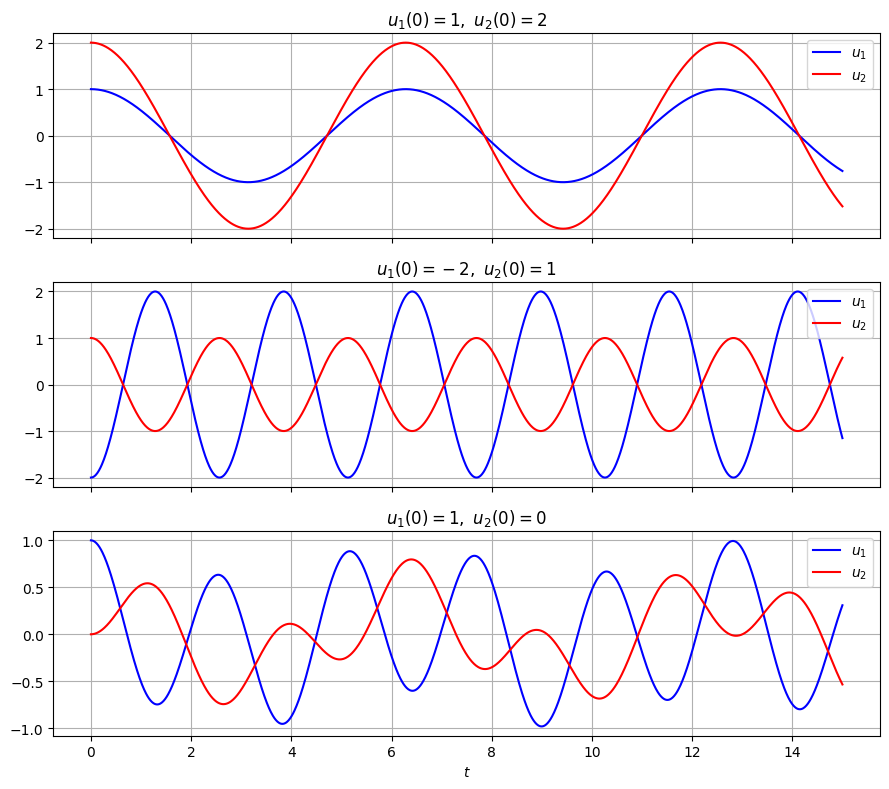

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

def duas_massas(estado, t):
    u1, v1, u2, v2 = estado
    return [v1, -5*u1 + 2*u2, v2, 2*u1 - 2*u2]

t = np.linspace(0, 15, 1500)
casos = [
    ("$u_1(0)=1,\\ u_2(0)=2$", [1, 0, 2, 0]),
    ("$u_1(0)=-2,\\ u_2(0)=1$", [-2, 0, 1, 0]),
    ("$u_1(0)=1,\\ u_2(0)=0$", [1, 0, 0, 0]),
]

fig, axs = plt.subplots(3, 1, figsize=(9, 8), sharex=True)
for ax, (titulo, ci) in zip(axs, casos):
    sol = odeint(duas_massas, ci, t)
    ax.plot(t, sol[:, 0], 'b', label='$u_1$')
    ax.plot(t, sol[:, 2], 'r', label='$u_2$')
    ax.set_title(titulo)
    ax.grid(True)
    ax.legend(loc='upper right')
axs[-1].set_xlabel("$t$")
plt.tight_layout()
plt.show()

y(x) = q*x*(-L + x)*(-L**2 - L*x + x**2)/(24*EI)
deflexão máxima y(L/2) = 5*L**4*q/(384*EI)


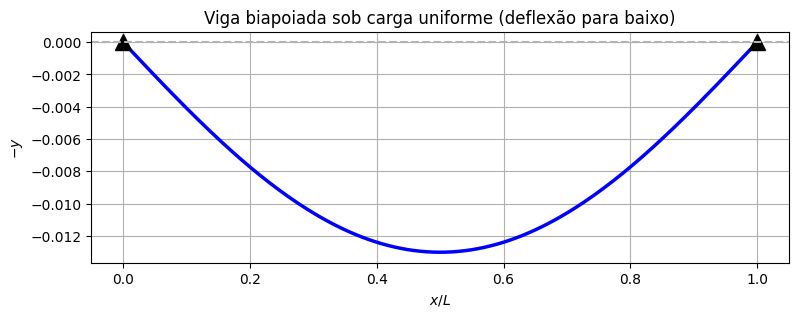

In [2]:
import sympy as sp

x, L, q, EI = sp.symbols('x L q EI', positive=True)
C1, C2, C3, C4 = sp.symbols('C1:5')

y_geral = q*x**4/(24*EI) + (C1*x**3/6 + C2*x**2/2 + C3*x + C4)/EI
condicoes = [y_geral.subs(x, 0), y_geral.subs(x, L),
             sp.diff(y_geral, x, 2).subs(x, 0), sp.diff(y_geral, x, 2).subs(x, L)]
constantes = sp.solve(condicoes, [C1, C2, C3, C4])

y_viga = sp.factor(y_geral.subs(constantes))
print("y(x) =", y_viga)
print("deflexão máxima y(L/2) =", sp.simplify(y_viga.subs(x, L/2)))

xs = np.linspace(0, 1, 200)
ys = xs*(1 - 2*xs**2 + xs**3)/24   # q = EI = L = 1

plt.figure(figsize=(9, 3))
plt.plot(xs, -ys, 'b', linewidth=2.5)
plt.plot([0, 1], [0, 0], 'k^', markersize=12)
plt.axhline(0, color='0.7', linestyle='--')
plt.title("Viga biapoiada sob carga uniforme (deflexão para baixo)")
plt.xlabel("$x/L$"); plt.ylabel("$-y$")
plt.grid(True)
plt.show()